In [ ]:
!pip install pyagrum
!pip install numpy
!pip install pandas
!pip install pingouin
!pip install bnlearn
!pip install graphviz

In [1]:
import sys
import os
sys.path.append(os.getcwd())

In [2]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import bnlearn as bn
from FCI_family import *
from FCI_pyagrum import *
from drawing_graph import * 
import graphviz

C:\Users\vuale\AppData\Roaming\Python\Python313\site-packages\bnlearn\__init__.py:22: RuntimeWarning: [bnlearn] Using 'threading' backend instead of 'loky' because Windows + Python 3.13.2 causes joblib/loky crashes.
  warnings.warn(


In [3]:
model = bn.import_DAG("asia")

[bnlearn] >Import <asia>
[bnlearn] >Loading bif file <C:\Users\vuale\AppData\Roaming\Python\Python313\site-packages\datazets\data\asia.bif>
[bnlearn] >[CPD > Validate] >[Node asia] >OK
[bnlearn] >[CPD > Validate] >[Node bronc] >OK
[bnlearn] >[CPD > Validate] >[Node dysp] >OK
[bnlearn] >[CPD > Validate] >[Node either] >OK
[bnlearn] >[CPD > Validate] >[Node lung] >OK
[bnlearn] >[CPD > Validate] >[Node smoke] >OK
[bnlearn] >[CPD > Validate] >[Node tub] >OK
[bnlearn] >[CPD > Validate] >[Node xray] >OK


In [ ]:
bn.plot(model)

In [4]:
df = bn.sampling(model, n=5000000)
df

,asia,tub,smoke,lung,bronc,either,xray,dysp
0,1,1,0,1,1,1,1,1
1,1,1,1,1,1,1,1,1
2,1,1,0,1,1,1,1,1
3,1,1,0,1,0,1,1,0
4,1,1,1,1,0,1,1,1
...,...,...,...,...,...,...,...,...
4999995,1,1,0,1,0,1,1,1
4999996,1,1,0,1,1,1,1,0
4999997,1,1,1,1,1,1,1,1
4999998,1,1,0,1,0,1,1,0


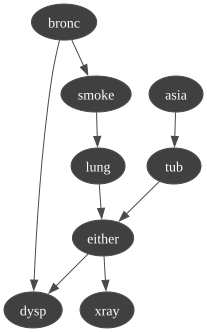

In [5]:
learner = gum.BNLearner(df)
learner.useMIIC()
bn_miic = learner.learnBN()
gnb.showBN(bn_miic)

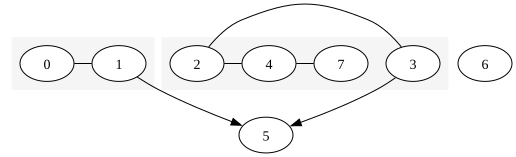

In [6]:
fci_pc = FCI_PC_pyagrum(df, 0.05)
dpag = fci_pc.return_PDAG()
graph = graphviz.Source(dpag.toDot())
graph

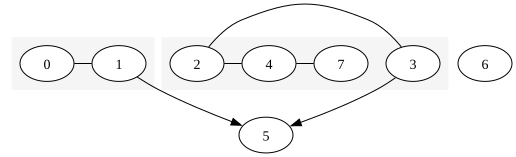

In [7]:
fci_zhang = FCI_Zhang_pyagrum(df, 0.05)
dpag = fci_zhang.return_PDAG()
graph = graphviz.Source(dpag.toDot())
graph

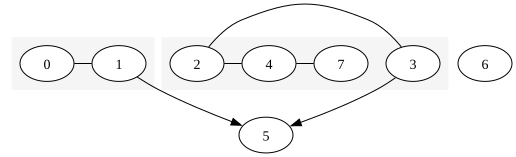

In [8]:
fci_ethz = FCI_ETHZ_pyagrum(df, 0.05)
dpag = fci_ethz.return_PDAG()
graph = graphviz.Source(dpag.toDot())
graph

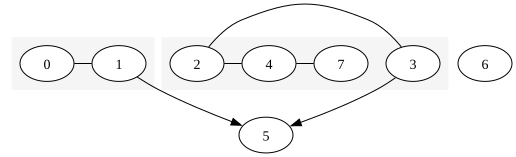

In [9]:
afci = AFCI_Zhang_pyagrum(df, 0.05)
dpag = afci.return_PDAG()
graph = graphviz.Source(dpag.toDot())
graph

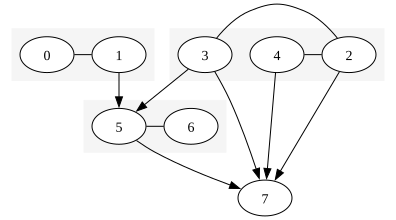

In [10]:
fci_pc_bis = create_instance(df, FCI_PC)
dpag = create_graph(fci_pc_bis)
graph = graphviz.Source(dpag.toDot())
graph

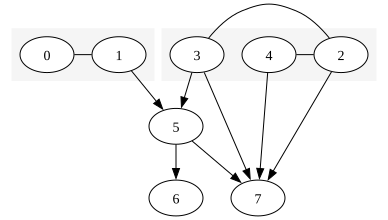

In [11]:
fci_zhang_bis = create_instance(df, FCI_Zhang)
dpag = create_graph(fci_zhang_bis)
graph = graphviz.Source(dpag.toDot())
graph

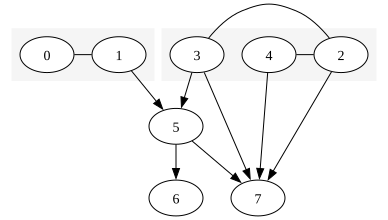

In [12]:
fci_ethz_bis = create_instance(df, FCI_ETHZ)
dpag = create_graph(fci_ethz_bis)
graph = graphviz.Source(dpag.toDot())
graph

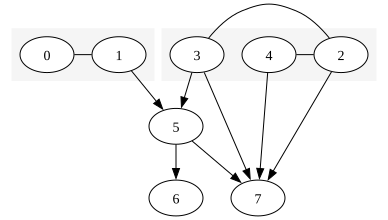

In [13]:
afci_bis = create_instance(df, FCI_Zhang)
dpag = create_graph(afci_bis)
graph = graphviz.Source(dpag.toDot())
graph